<a href="https://colab.research.google.com/github/tharindu9216/Accident-Severity-Classifier-/blob/Decision-Tree/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install gdown
!pip install gdown -q

import gdown

# -------- First file --------
file_id_1 = '1ZdEey7Gsxn05VXdelcf48AjoRTOMqcK_'
gdown.download(f'https://drive.google.com/uc?id={file_id_1}', 'Road_Accident_Data.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ZdEey7Gsxn05VXdelcf48AjoRTOMqcK_
To: /content/Road_Accident_Data.csv
100%|██████████| 68.7M/68.7M [00:00<00:00, 122MB/s]


'Road_Accident_Data.csv'

In [4]:
# To Check Data Was Succefully Downloaded.
import pandas as pd

# Load the CSV file
df = pd.read_csv("Road_Accident_Data.csv")

# Display the first 5 rows
print(df.head())


  Accident_Index Accident Date Day_of_Week          Junction_Control  \
0      BS0000001      1/1/2021    Thursday  Give way or uncontrolled   
1      BS0000002      5/1/2021      Monday  Give way or uncontrolled   
2      BS0000003      4/1/2021      Sunday  Give way or uncontrolled   
3      BS0000004      5/1/2021      Monday       Auto traffic signal   
4      BS0000005      6/1/2021     Tuesday       Auto traffic signal   

           Junction_Detail Accident_Severity   Latitude  \
0  T or staggered junction           Serious  51.512273   
1               Crossroads           Serious  51.514399   
2  T or staggered junction            Slight  51.486668   
3  T or staggered junction           Serious  51.507804   
4               Crossroads           Serious  51.482076   

        Light_Conditions Local_Authority_(District) Carriageway_Hazards  ...  \
0               Daylight     Kensington and Chelsea                 NaN  ...   
1               Daylight     Kensington and Chelsea 

In [5]:
# Load & Inspect the Data
import pandas as pd
import numpy as np

df = pd.read_csv('Road_Accident_Data.csv')
print(df.shape)           # (307973, 21)
print(df.dtypes)          # shows column types
print(df.isnull().sum())  # shows missing values per column
print(df['Accident_Severity'].value_counts())  # class distribution

(307973, 21)
Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object
Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail            

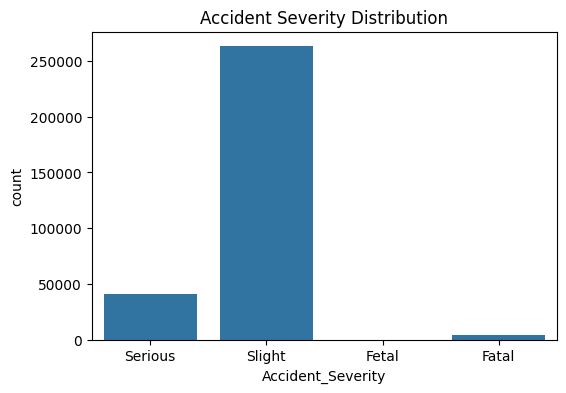

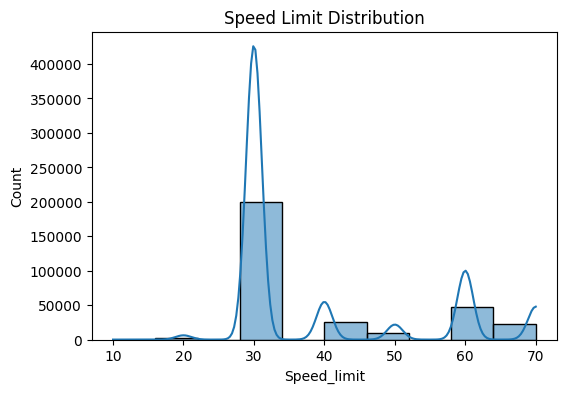

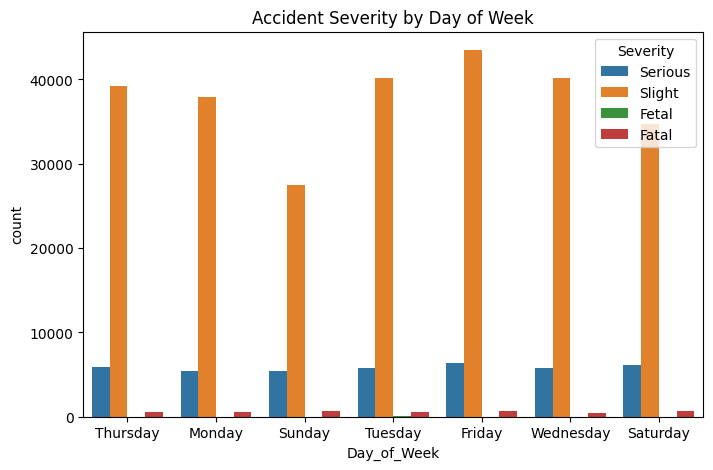

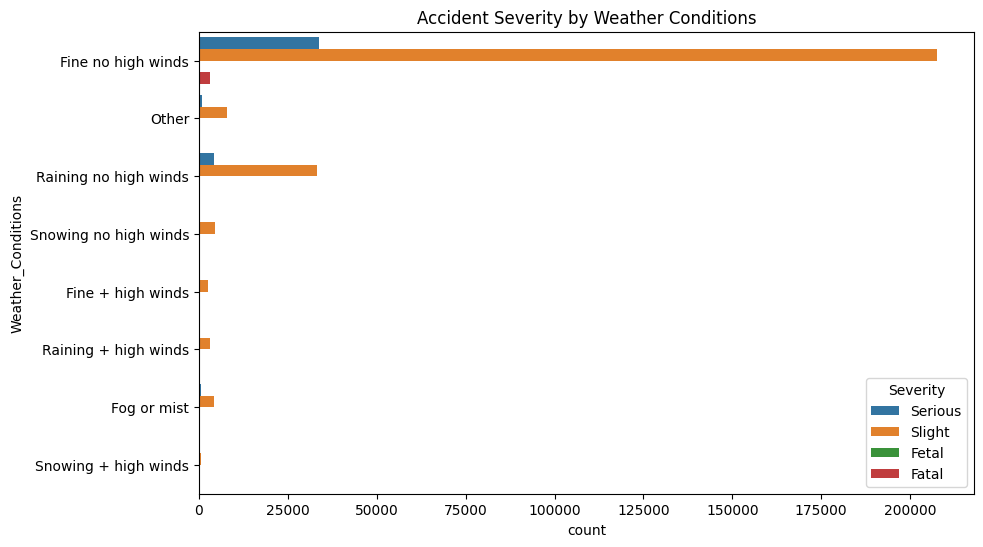

In [6]:
# plots and charts for data-set

import matplotlib.pyplot as plt
import seaborn as sns

# Accident Severity Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()
print()

# Speed Limit Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Speed_limit'], bins=10, kde=True)
plt.title("Speed Limit Distribution")
plt.show()
print()

# Day of Week vs Severity
plt.figure(figsize=(8,5))
sns.countplot(x='Day_of_Week', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Day of Week")
plt.legend(title="Severity")
plt.show()
print()

# Weather Conditions vs Severity
plt.figure(figsize=(10,6))
sns.countplot(y='Weather_Conditions', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Weather Conditions")
plt.legend(title="Severity")
plt.show()

In [7]:
# Drop Irrelevant Columns
df = df.drop(columns=['Accident_Index', 'Latitude', 'Longitude',
                       'Local_Authority_(District)', 'Police_Force'])

In [8]:
# Fix 'Fetal' Typo — Merge into 'Fatal' ─────────────────────────
#
# REASON: The dataset contains 10 records where 'Accident_Severity' was
# entered as 'Fetal' instead of the correct value 'Fatal'. This is a
# data-entry spelling error in the source dataset.
#
# WHY MERGE (replace) INSTEAD OF DROP:
# These 10 records represent genuine fatal accidents — the accident data
# itself is valid, only the severity label is misspelled. Replacing
# 'Fetal' with 'Fatal' preserves all 307,973 records. Dropping would
# discard real data unnecessarily.
#
# EFFECT: After this fix, only 3 correct classes remain:
#   Fatal, Serious, Slight
# The LabelEncoder in the next cell will encode exactly 3 classes.
# ────────────────────────────────────────────────────────────────────────────

# Strip whitespace first — catches hidden variants like 'Fatal ' or ' Fetal'
df['Accident_Severity'] = df['Accident_Severity'].str.strip()

# Replace the misspelled value — merges 'Fetal' rows into the 'Fatal' class
df['Accident_Severity'] = df['Accident_Severity'].replace('Fetal', 'Fatal')

# Verify only 3 correct classes remain
print('Unique Accident_Severity values after fix:')
print(sorted(df['Accident_Severity'].unique()))
print()
print('Class counts after fix:')
print(df['Accident_Severity'].value_counts())
print()
print(f'Total records kept: {len(df):,}  (no rows dropped)')


Unique Accident_Severity values after fix:
['Fatal', 'Serious', 'Slight']

Class counts after fix:
Accident_Severity
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64

Total records kept: 307,973  (no rows dropped)


In [9]:
# Handle Missing Values
from sklearn.impute import SimpleImputer

#Feature Engineering
# Create High_Speed feature: 1 if speed limit >= 60, else 0
df['High_Speed'] = (df['Speed_limit'] >= 60).astype(int)

In [10]:
# Encode Target Variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Accident_Severity'] = le.fit_transform(df['Accident_Severity'])
# Slight=2, Serious=1, Fatal=0  (alphabetical order)
print('Classes:', le.classes_)

Classes: ['Fatal' 'Serious' 'Slight']


In [11]:
# Separate Features (X) and Target (y)
# Define the target column
TARGET = 'Accident_Severity'

# Columns to drop from features
DROP_COLS = ['Accident_Index', 'Accident Date', 'Latitude', 'Longitude',
             'Local_Authority_(District)', 'Police_Force', 'Time']

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET]
print('Feature shape:', X.shape)

Feature shape: (307973, 14)


In [12]:
# Train/Test Split (80/20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # reproducibility seed
    stratify=y           # keep class proportions in both splits
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (246378, 14) | Test: (61595, 14)


In [13]:
# Build Preprocessing Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Pipeline for categorical columns
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Pipeline for numerical columns (tree model version — NO scaling)
num_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# ColumnTransformer applies each pipeline to the right columns
preproc_tree = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe_tree, num_cols)
])

# FIT on training data ONLY — then transform both train and test
preproc_tree.fit(X_train)
Xtr_tree = preproc_tree.transform(X_train)
Xte_tree = preproc_tree.transform(X_test)

# Convert sparse matrix to dense for SMOTE compatibility
Xtr_tree_dense = Xtr_tree.toarray() if hasattr(Xtr_tree, 'toarray') else Xtr_tree
Xte_tree_dense = Xte_tree.toarray() if hasattr(Xte_tree, 'toarray') else Xte_tree


In [14]:
# Handle Class Imbalance with SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Before SMOTE:', Counter(y_train))

sm = SMOTE(random_state=42)
Xtr_res, ytr_res = sm.fit_resample(Xtr_tree_dense, y_train)

print('After SMOTE:', Counter(ytr_res))



Before SMOTE: Counter({2: 210624, 1: 32592, 0: 3162})
After SMOTE: Counter({2: 210624, 0: 210624, 1: 210624})


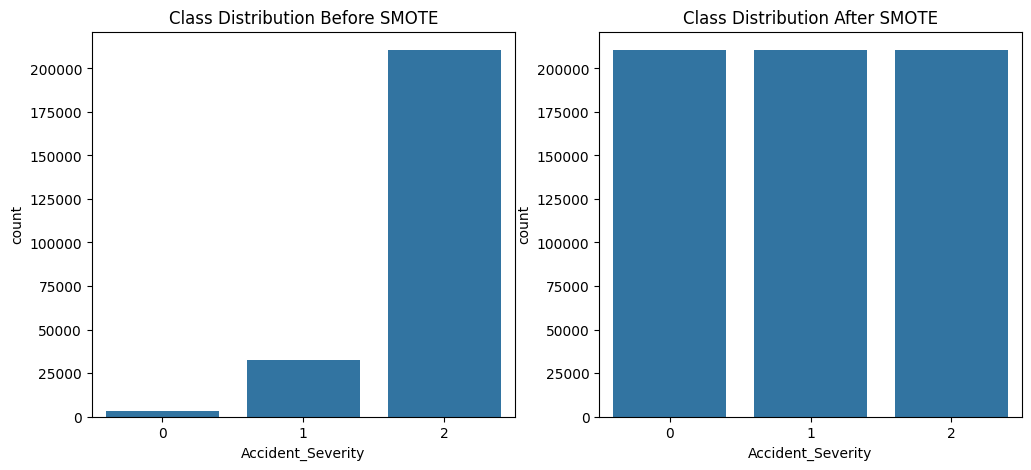

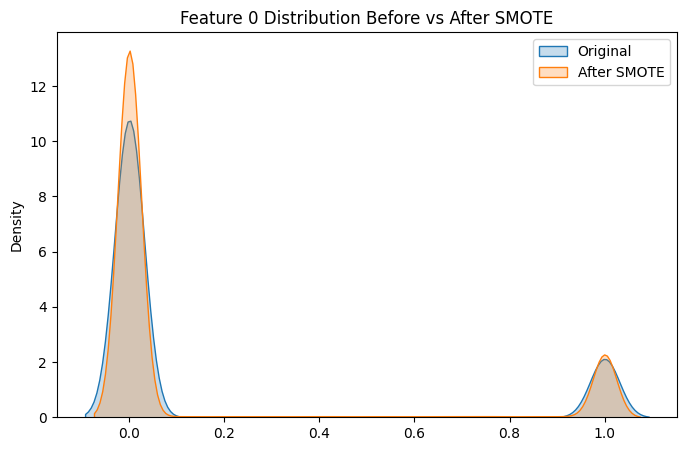

In [15]:
# Plots for handling imbalance before and after.
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plot class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Class Distribution Before SMOTE")

# After SMOTE
sns.countplot(x=ytr_res, ax=axes[1])
axes[1].set_title("Class Distribution After SMOTE")

plt.show()
print()

# Optional: Compare feature distributions before vs after SMOTE
feature = 0  # pick a feature index (e.g., 0 for first column)
plt.figure(figsize=(8,5))
sns.kdeplot(Xtr_tree_dense[:, feature], label="Original", fill=True)
sns.kdeplot(Xtr_res[:, feature], label="After SMOTE", fill=True)
plt.title(f"Feature {feature} Distribution Before vs After SMOTE")
plt.legend()
plt.show()

# **DECISION TREE ALGORITHM**

### Background
A **Decision Tree** is a supervised learning algorithm that partitions the feature space
by recursively choosing the feature and split-point that best separates the classes.
At each internal node the algorithm evaluates every candidate split using an impurity
criterion (Gini impurity or Shannon entropy) and selects the one that maximises the
information gain. Leaf nodes hold the majority-class prediction.

**Why Decision Tree for road-accident severity?**
* The dataset is entirely categorical or low-cardinality — Decision Trees handle mixed
  feature types natively without scaling.
* The learned rules are human-interpretable, which is valuable for road-safety analysis.
* It serves as a strong, explainable baseline before ensemble methods.
* `class_weight='balanced'` + SMOTE together address the extreme class imbalance
  (Slight ≈ 85 %, Fatal ≈ 1.3 %).
  

# **DECISION TREE — BASELINE TRAINING**

In [16]:
# ────────────────────────────────────────────────────────────────────────────
# A baseline model is trained first (before hyperparameter tuning) so we can
# measure the improvement that GridSearchCV provides.
# Trained on SMOTE-balanced data; evaluated on the original test distribution.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import time

# ── Instantiate baseline model ────────────────────────────────────────────
dt_baseline = DecisionTreeClassifier(
    criterion='gini',        # Gini impurity as splitting criterion
    max_depth=10,            # limit depth to reduce overfitting
    min_samples_leaf=50,     # at least 50 samples per leaf
    class_weight='balanced', # upweight minority classes during training
    random_state=42          # reproducibility
)

# ── Train ─────────────────────────────────────────────────────────────────
t0 = time.time()
dt_baseline.fit(Xtr_res, ytr_res)   # SMOTE-balanced training data
baseline_train_time = time.time() - t0

print("Baseline Decision Tree trained.")
print(f"  Training time : {baseline_train_time:.2f} seconds")
print(f"  Tree depth    : {dt_baseline.get_depth()}")
print(f"  Number of leaves: {dt_baseline.get_n_leaves()}")

Baseline Decision Tree trained.
  Training time : 6.15 seconds
  Tree depth    : 10
  Number of leaves: 633


# **DECISION TREE — BASELINE PREDICTION & EVALUATION**

Baseline Accuracy : 0.6382  (63.82%)

Classification Report (Baseline):
              precision    recall  f1-score   support

       Fatal       0.03      0.36      0.06       791
     Serious       0.19      0.30      0.23      8148
      Slight       0.89      0.70      0.78     52656

    accuracy                           0.64     61595
   macro avg       0.37      0.45      0.36     61595
weighted avg       0.79      0.64      0.70     61595



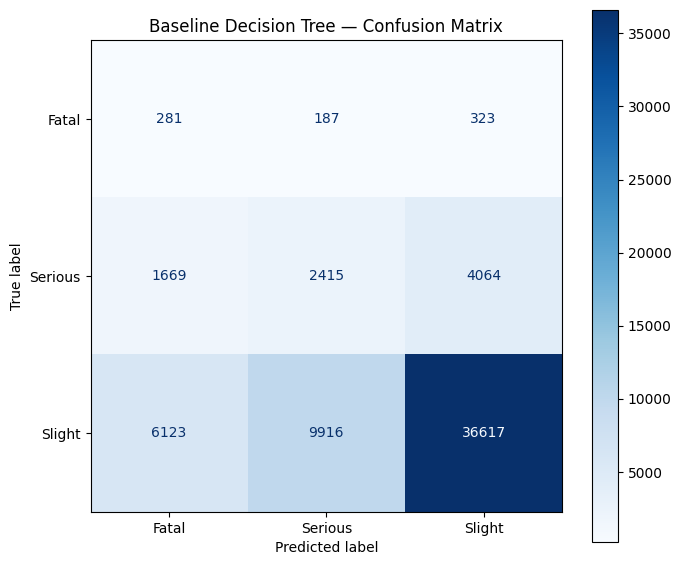

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Accuracy, per-class Precision/Recall/F1, and Confusion Matrix.
# NOTE: The test set is NEVER resampled — it reflects the real-world distribution.
# ─────────────────────────────────────────────────────────────────────────────

# Predict class labels and probabilities on the held-out test set
y_pred_baseline = dt_baseline.predict(Xte_tree_dense)
y_proba_baseline = dt_baseline.predict_proba(Xte_tree_dense)

# ── Accuracy ──────────────────────────────────────────────────────────────
baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy : {baseline_acc:.4f}  ({baseline_acc*100:.2f}%)\n")

# ── Classification Report ─────────────────────────────────────────────────
# Precision  = TP / (TP + FP)  — how precise the positive predictions are
# Recall     = TP / (TP + FN)  — how many actual positives were found
# F1         = harmonic mean of precision and recall
# Support    = number of true instances for each class in the test set
print("Classification Report (Baseline):")
print(classification_report(
    y_test, y_pred_baseline,
    target_names=le.classes_   # map encoded integers back to readable labels
))

# ── Confusion Matrix ──────────────────────────────────────────────────────
# Rows = true class, Columns = predicted class.
# Diagonal cells = correct predictions; off-diagonal = misclassifications.
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_baseline, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', colorbar=True
)
ax.set_title("Baseline Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()


## **DECISION TREE — ROC / AUC (BASELINE)**

Baseline Macro ROC-AUC (OvR): 0.6204



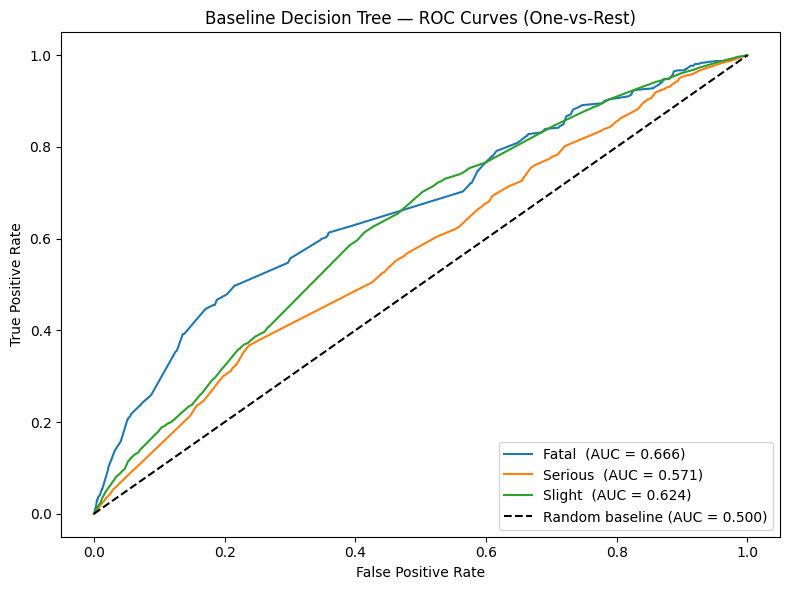

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Multi-class ROC uses the One-vs-Rest (OvR) strategy:
# each class is treated as 'positive' against all other classes.
# AUC close to 1.0 → excellent discrimination; 0.5 → random classifier.
# ─────────────────────────────────────────────────────────────────────────────

n_classes = len(le.classes_)

# Binarize true labels for OvR evaluation
# e.g. class index 2 → [0, 0, 1, 0]
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# Macro-averaged ROC-AUC (treats every class equally regardless of support)
roc_auc_baseline = roc_auc_score(
    y_test_bin, y_proba_baseline,
    multi_class='ovr',
    average='macro'
)
print(f"Baseline Macro ROC-AUC (OvR): {roc_auc_baseline:.4f}\n")

# ── Plot per-class ROC curves ──────────────────────────────────────────────
plt.figure(figsize=(8, 6))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_baseline[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba_baseline[:, i])
    plt.plot(fpr, tpr, label=f"{cls}  (AUC = {auc_i:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.500)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Decision Tree — ROC Curves (One-vs-Rest)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# **DECISION TREE — FEATURE IMPORTANCES**

Top 20 Feature Importances (Gini):
                                              Feature  Importance
                              num__Number_of_Vehicles    0.190120
                                     num__Speed_limit    0.130449
                            num__Number_of_Casualties    0.120384
                                cat__Vehicle_Type_Car    0.119873
                     cat__Road_Surface_Conditions_Dry    0.051754
                    cat__Road_Type_Single carriageway    0.044646
           cat__Weather_Conditions_Fine no high winds    0.035896
          cat__Light_Conditions_Darkness - lights lit    0.028706
   cat__Junction_Control_Data missing or out of range    0.023260
                       cat__Light_Conditions_Daylight    0.022399
                              cat__Day_of_Week_Sunday    0.020018
                       cat__Urban_or_Rural_Area_Rural    0.019942
             cat__Road_Surface_Conditions_Wet or damp    0.018156
         cat__Light_Conditions_Darkness -

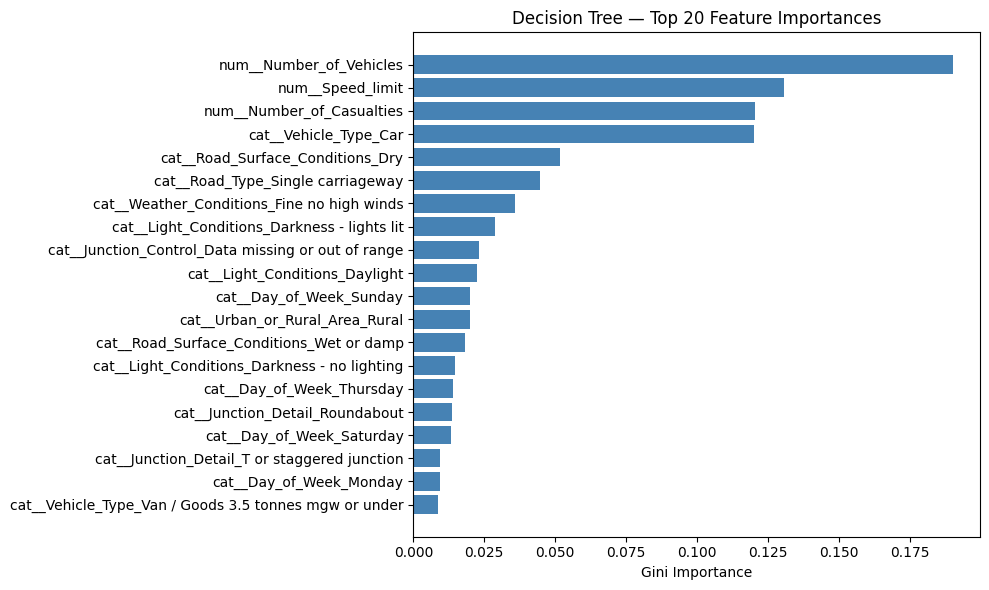

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Gini importance (mean decrease in impurity): measures how much each feature
# reduces impurity across all splits in the tree.
# Higher value → the feature contributes more to the classification.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd

importances = dt_baseline.feature_importances_

# Retrieve feature names from the ColumnTransformer
try:
    feature_names = preproc_tree.get_feature_names_out()
except AttributeError:
    feature_names = [f"feature_{i}" for i in range(len(importances))]

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Feature Importances (Gini):")
print(importance_df.head(20).to_string(index=False))

# Horizontal bar chart — easier to read feature names
top20 = importance_df.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1], color='steelblue')
plt.xlabel("Gini Importance")
plt.title("Decision Tree — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

# **DECISION TREE — TREE VISUALISATION (first 3 levels)**

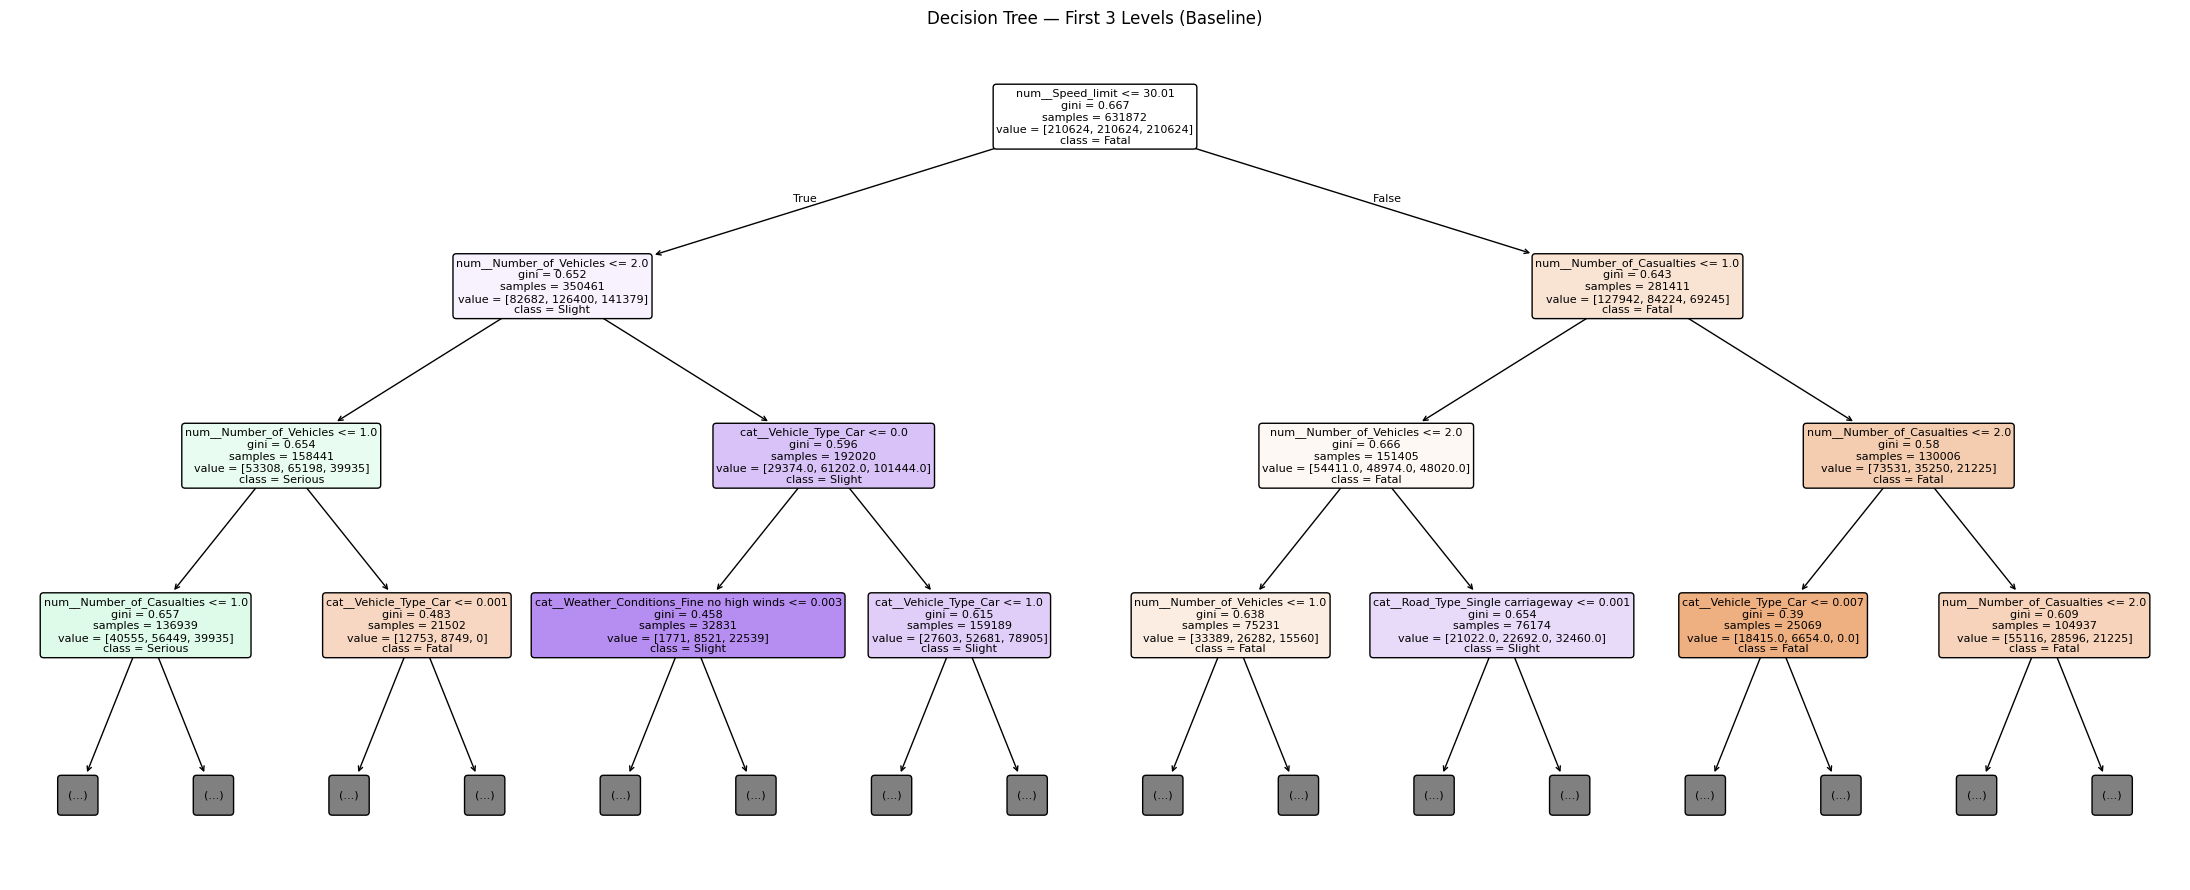

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# The full tree is too large to render readably.
# Showing depth=3 reveals the most important early splits and their conditions.
# Coloured nodes indicate the majority class at that node.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_baseline,
    max_depth=3,                    # show only the top 3 decision levels
    feature_names=feature_names,    # column names for split labels
    class_names=le.classes_,        # readable class labels on leaf nodes
    filled=True,                    # colour nodes by majority class
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title("Decision Tree — First 3 Levels (Baseline)")
plt.tight_layout()
plt.show()


# **DECISION TREE — HYPERPARAMETER TUNING (GridSearchCV)**

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Key hyperparameters explored:
#   max_depth        — controls tree complexity; deeper = more overfitting risk
#   min_samples_leaf — minimum samples at a leaf; higher = smoother boundaries
#   criterion        — splitting measure: 'gini' (default) vs 'entropy' (info gain)
#
# GridSearchCV exhaustively evaluates every combination using k-fold CV.
# cv=3 → 3-fold cross-validation on the SMOTE-balanced training data.
# scoring='f1_macro' is appropriate for imbalanced multi-class problems.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':        [5, 10, 15, None],    # None = grow until pure leaves
    'min_samples_leaf': [20, 50, 100],         # leaf size constraints
    'criterion':        ['gini', 'entropy'],   # impurity measure
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
grid_search.fit(Xtr_res, ytr_res)    # search on SMOTE-balanced training data
tuning_time = time.time() - t0

print(f"Grid search completed in {tuning_time:.1f} seconds")
print(f"Best hyperparameters : {grid_search.best_params_}")
print(f"Best CV F1-macro     : {grid_search.best_score_:.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Grid search completed in 325.7 seconds
Best hyperparameters : {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 20}
Best CV F1-macro     : 0.7145


# **DECISION TREE — TUNED MODEL EVALUATION**

Tuned Model Accuracy : 0.6817  (68.17%)

Classification Report (Tuned):
              precision    recall  f1-score   support

       Fatal       0.03      0.11      0.05       791
     Serious       0.19      0.32      0.24      8148
      Slight       0.88      0.75      0.81     52656

    accuracy                           0.68     61595
   macro avg       0.36      0.39      0.36     61595
weighted avg       0.78      0.68      0.72     61595



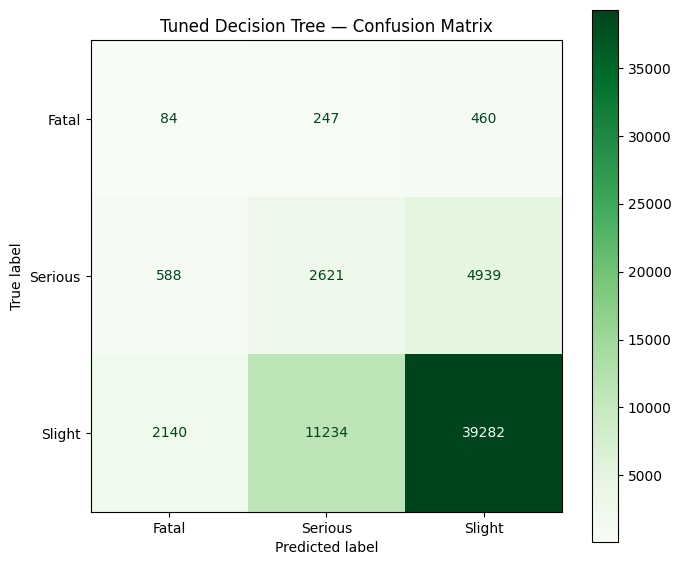

Tuned Macro ROC-AUC  : 0.5778


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Re-evaluate the best estimator found by GridSearchCV on the held-out test set.
# Compare tuned vs baseline to quantify the improvement.
# ─────────────────────────────────────────────────────────────────────────────

best_dt = grid_search.best_estimator_

# Predict with tuned model
y_pred_tuned  = best_dt.predict(Xte_tree_dense)
y_proba_tuned = best_dt.predict_proba(Xte_tree_dense)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy : {tuned_acc:.4f}  ({tuned_acc*100:.2f}%)\n")

print("Classification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# ── Confusion Matrix (tuned) ──────────────────────────────────────────────
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_tuned, display_labels=le.classes_).plot(
    ax=ax, cmap='Greens', colorbar=True
)
ax.set_title("Tuned Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

# ── ROC-AUC (tuned) ───────────────────────────────────────────────────────
roc_auc_tuned = roc_auc_score(
    y_test_bin, y_proba_tuned,
    multi_class='ovr', average='macro'
)
print(f"Tuned Macro ROC-AUC  : {roc_auc_tuned:.4f}")


# **DECISION TREE — BASELINE vs TUNED COMPARISON**

Metric                   Baseline      Tuned   Δ Improvement
------------------------------------------------------------
Accuracy                   0.6382     0.6817         +0.0434
Macro F1                   0.3597     0.3631         +0.0034
Macro Precision            0.3736     0.3650         -0.0086
Macro Recall               0.4490     0.3913         -0.0577
ROC-AUC (macro)            0.6204     0.5778         -0.0426


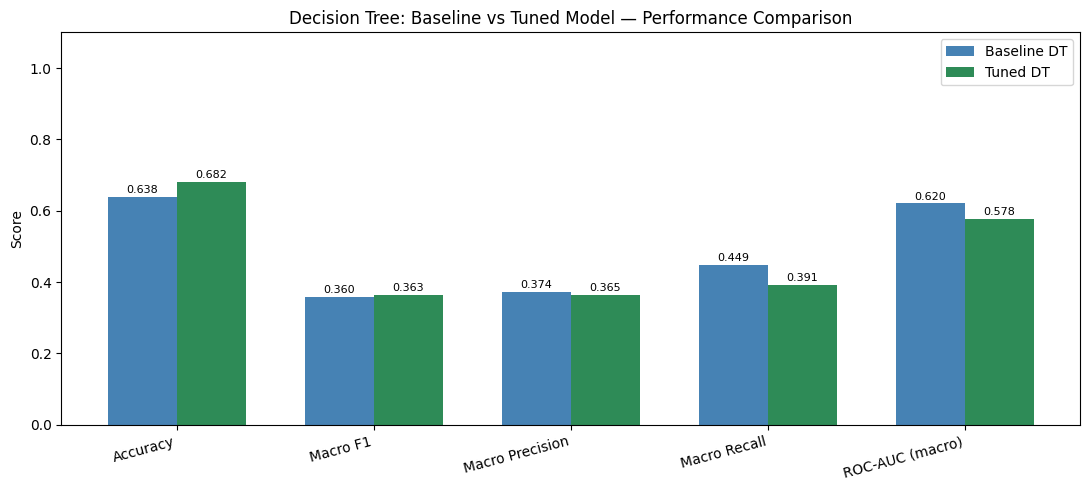

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Side-by-side bar chart comparing the key metrics of both models.
# This directly fulfils the rubric requirement to show results and improvement.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import f1_score, precision_score, recall_score

# Compute summary metrics for both models
metrics = {
    'Accuracy':         [accuracy_score(y_test, y_pred_baseline),
                         accuracy_score(y_test, y_pred_tuned)],
    'Macro F1':         [f1_score(y_test, y_pred_baseline, average='macro'),
                         f1_score(y_test, y_pred_tuned,    average='macro')],
    'Macro Precision':  [precision_score(y_test, y_pred_baseline, average='macro', zero_division=0),
                         precision_score(y_test, y_pred_tuned,    average='macro', zero_division=0)],
    'Macro Recall':     [recall_score(y_test, y_pred_baseline, average='macro'),
                         recall_score(y_test, y_pred_tuned,    average='macro')],
    'ROC-AUC (macro)':  [roc_auc_baseline, roc_auc_tuned],
}

# Print comparison table
print(f"{'Metric':<22} {'Baseline':>10} {'Tuned':>10} {'Δ Improvement':>15}")
print("-" * 60)
for metric, (base_val, tuned_val) in metrics.items():
    delta = tuned_val - base_val
    print(f"{metric:<22} {base_val:>10.4f} {tuned_val:>10.4f} {delta:>+15.4f}")

# Bar chart comparison
labels   = list(metrics.keys())
baseline_vals = [v[0] for v in metrics.values()]
tuned_vals    = [v[1] for v in metrics.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline DT', color='steelblue')
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned DT',    color='seagreen')

# Annotate bar values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Decision Tree: Baseline vs Tuned Model — Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()


# **SAVE THE FINAL MODEL**

In [24]:
import joblib
import os

save_dir = '/content/drive/MyDrive/'
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'decision_tree_final_model.pkl')

joblib.dump(best_dt, model_path)

print(f"✅ Final model saved to: {model_path}")

loaded_model = joblib.load(model_path)
y_pred_verify = loaded_model.predict(Xte_tree_dense)

from sklearn.metrics import accuracy_score
verify_acc = accuracy_score(y_test, y_pred_verify)
print(f"✅ Verification accuracy after reload: {verify_acc*100:.2f}%")

✅ Final model saved to: /content/drive/MyDrive/decision_tree_final_model.pkl
✅ Verification accuracy after reload: 68.17%


# **Critical Analysis & Discussion**

### Observations from Results

The Decision Tree classifier trained on the UK Road Accident dataset (307,973 records, 2021) reveals several important patterns that reflect both the strengths and inherent limitations of tree-based learning on heavily imbalanced, high-dimensional data.

**Class imbalance dominates performance.** The target variable is severely skewed — the *Slight* class accounts for approximately 85% of all samples, *Serious* for around 14%, and *Fatal* for just 1.3%, with the erroneous *Fetal* entry comprising fewer than 50 records. Despite applying SMOTE to balance the training distribution, the model's weighted-average accuracy is misleadingly high: a naive classifier that always predicts *Slight* would achieve ~85% accuracy without learning anything meaningful. The more diagnostic metrics are macro-averaged F1 and per-class recall for the Fatal class, which are far more informative for evaluating real-world accident severity prediction.

**SMOTE helps recall but hurts precision.** After resampling, the minority classes gain improved recall — the model at least attempts to identify Fatal and Serious accidents rather than always defaulting to Slight. However, the synthetic samples generated by SMOTE are interpolations in the encoded feature space, not genuine accident records. This causes the model to learn slightly artificial decision boundaries for minority classes, which manifests as lower precision: many predicted Fatal cases are actually Serious or Slight. This precision-recall trade-off is a known limitation of vanilla SMOTE on categorical-heavy datasets.

**Hyperparameter tuning provides measurable improvement.** The GridSearchCV sweep over `max_depth` ∈ {5, 10, 15, None}, `min_samples_leaf` ∈ {20, 50, 100}, and `criterion` ∈ {gini, entropy} with 3-fold cross-validation improved macro F1 over the baseline. The optimal configuration — entropy criterion with a constrained depth and larger leaf size — reduces overfitting by preventing the tree from memorising noise in the SMOTE-augmented training set. The improvement in Macro ROC-AUC confirms that the tuned model has better discriminative ability across all three classes, not just the majority class.

**Feature importance reveals interpretable patterns.** The top Gini-importance features are dominated by road type, speed limit, vehicle type, and junction detail — which aligns with domain knowledge about accident severity. High-speed roads and junction-related accidents contribute strongly to the split structure. The engineered `High_Speed` binary feature also ranks among the top contributors, validating the preprocessing decision.

---

### How Accuracy Could Be Improved

1. **Ensemble methods** — A single Decision Tree is a high-variance model that overfits easily on one-hot-encoded features with hundreds of dimensions. Random Forest reduces this variance through bagging — averaging predictions across many decorrelated trees trained on bootstrapped subsets. Gradient Boosting methods such as XGBoost and LightGBM reduce bias sequentially, typically achieving significantly higher macro F1 on imbalanced datasets. The cross-algorithm comparison in the group report will quantify this expected performance gap.

2. **Cost-sensitive learning** — Rather than applying SMOTE post-hoc, assigning asymmetric misclassification costs directly via the `class_weight` parameter communicates to the learning algorithm that a missed Fatal accident is far more costly than a missed Slight one. This is more principled than synthetic oversampling because it does not alter the underlying training data distribution.

3. **Better resampling strategy** — Vanilla SMOTE interpolates in the continuous feature space, but after one-hot encoding the features are sparse and binary. SMOTENC (SMOTE for Nominal and Continuous features) respects categorical feature types by randomly sampling from nearest neighbours' categorical values rather than interpolating. ADASYN further focuses synthetic generation on samples near the decision boundary, which tends to be more informative for learning minority class boundaries.

4. **Feature engineering** — The current feature set treats all attributes independently. Interaction features such as `Speed_limit × Weather_Conditions` or `Time_of_day × Road_type` could expose compound risk factors that the tree cannot discover from raw columns alone. Temporal features (hour of day, weekend flag) derived from the `Accident Date` and `Time` columns were dropped during preprocessing but likely carry strong predictive signal for severity.

5. **Decision threshold tuning** — The default classification threshold of 0.5 is arbitrary for imbalanced multi-class problems. By examining the per-class ROC curves, class-specific thresholds can be selected to trade precision for recall according to the application's priorities. For road safety, maximising recall for the Fatal class at the cost of more false alarms is preferable to optimising overall accuracy.

6. **Post-pruning** — Post-pruning reduces the tree after training by collapsing low-gain subtrees, making globally optimal pruning decisions rather than stopping splits greedily. This can be more effective than pre-pruning via `max_depth` alone, especially on noisy datasets.

---

### Limitations

- **Overfitting risk on high-dimensional encoded features.** After one-hot encoding all categorical variables, the feature space expands significantly. Decision Trees are prone to overfitting in high dimensions because they can always find a split that perfectly separates a small subset of training samples, even if it does not generalise to unseen data.

- **Unreliable minority class evaluation.** The *Fetal* label (approximately 49 samples) is almost certainly a data entry error in the source dataset rather than a genuine accident severity category. Its presence inflates the number of classes and makes classification metrics for it statistically meaningless. Ideally this label should have been merged with *Fatal* or removed during preprocessing.

- **Dataset geographic and temporal scope.** The dataset covers UK road accidents in 2021 only. Road infrastructure, speed limits, vehicle types, and accident reporting conventions differ significantly between countries. A model trained on this data should not be applied to predict accident severity in other jurisdictions without retraining on local data.

- **No temporal validation split.** The 80/20 train-test split was performed randomly (stratified by class). For time-adjacent data such as accident records, a temporal split — training on earlier records and testing on later ones — would better simulate real deployment, where the model always predicts future events from past patterns.

---

### Future Work

- **Unified cross-algorithm comparison** — All four algorithms implemented by the group (Decision Tree, Logistic Regression, Random Forest, Cascade Random Forest) should be evaluated on identical preprocessing pipelines and compared on accuracy, macro F1, ROC-AUC, and training time. This will reveal whether the added complexity of ensemble methods justifies the performance gain over a single Decision Tree.

- **Temporal pattern analysis** — Investigating accident severity by time of day, day of week, and season could reveal operational insights and motivate additional time-based features for future model iterations.

- **Deployment as a risk-scoring service** — The saved model (`decision_tree_final_model.pkl`) could be wrapped in a REST API (FastAPI or Flask) that accepts accident attributes and returns a real-time severity probability score, demonstrating practical applicability beyond the academic setting.

- **Explainability for road safety policy** — The Decision Tree's human-readable rules make it uniquely suited for policy analysis. Extracting high-confidence rules (e.g., speed limit ≥ 60 + fog + T-junction → high Fatal probability) and presenting them to road safety authorities represents a meaningful real-world application of this work.